SECTION 1: SETUP AND IMPORTS

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)


SECTION 2: CONFIGURATION 

In [2]:
DATA_DIRECTORY = r"C:\MATH699P\Data"

PROCESSED_DIR = os.path.join(DATA_DIRECTORY, 'processed_data')
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Data Directory: {DATA_DIRECTORY}")
print(f"Output Directory: {PROCESSED_DIR}\n")

Data Directory: C:\MATH699P\Data
Output Directory: C:\MATH699P\Data\processed_data



SECTION 3: FILE DISCOVERY AND INVENTORY

In [3]:
class CSVDatabaseInventory:
    """Discover and catalog all CSV files in the data directory"""
    
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.inventory = {}
        
    def scan_directory(self):
        """Scan directory and create inventory of all CSV files"""
        
        print(f"Scanning directory: {self.data_dir}")
        print("-" * 80)
        
        if not os.path.exists(self.data_dir):
            print(f"ERROR: Directory does not exist: {self.data_dir}")
            return self.inventory
        
        csv_files = [f for f in os.listdir(self.data_dir) if f.lower().endswith('.csv')]
        
        if not csv_files:
            print(f"No CSV files found in {self.data_dir}")
            return self.inventory
        
        print(f"Found {len(csv_files)} CSV files\n")
        
        table_categories = {
            'ozone': [],
            'hourly_gas': [],
            'drychem': [],
            'drydep': [],
            'wet': [],
            'cloud': [],
            'purpleair': [],
            'calibration': [],
            'site': [],
            'plant': [],
            'total_deposition': [],
            'vischem': [],
            'visneph': [],
            'historic': [],
            'other': []
        }
        
        for filename in csv_files:
            file_path = os.path.join(self.data_dir, filename)
            base_name = filename.lower().replace('.csv', '')
            file_size = os.path.getsize(file_path) / (1024 * 1024)  
            
            category = 'other'
            
            if base_name == 'ozone' or base_name.startswith('ozone_'):
                category = 'ozone'
            elif base_name == 'hourly_gas' or ('hourly' in base_name and 'gas' in base_name):
                category = 'hourly_gas'
            elif base_name == 'drychem' or base_name.startswith('drychem_'):
                category = 'drychem'
            elif base_name.startswith('drydep'):
                category = 'drydep'
            elif 'wet' in base_name and ('concentration' in base_name or 'chem' in base_name):
                category = 'wet'
            elif base_name.startswith('cloud'):
                category = 'cloud'
            elif 'purpleair' in base_name or 'purple_air' in base_name:
                category = 'purpleair'
            elif 'calibration' in base_name or 'qc' in base_name or base_name.startswith('gas_calibration'):
                category = 'calibration'
            elif base_name == 'site' or (base_name.startswith('site') and 'plant' not in base_name):
                category = 'site'
            elif base_name.startswith('plant') or base_name == 'leaf_angle' or base_name.startswith('site_plant'):
                category = 'plant'
            elif 'total_deposition' in base_name or 'totaldeposition' in base_name:
                category = 'total_deposition'
            elif base_name == 'vischem':
                category = 'vischem'
            elif base_name == 'visneph':
                category = 'visneph'
            elif 'historic' in base_name:
                category = 'historic'
            
            table_categories[category].append({
                'filename': filename,
                'filepath': file_path,
                'size_mb': file_size,
                'category': category
            })
        
        self.inventory = table_categories
        
        print("\nFILE INVENTORY BY CATEGORY:")
        print("-" * 80)
        total_files = 0
        total_size = 0
        for category, files in table_categories.items():
            if files:
                cat_size = sum(f['size_mb'] for f in files)
                total_files += len(files)
                total_size += cat_size
                print(f"\n{category.upper()} ({len(files)} files, {cat_size:.2f} MB):")
                for f in files:
                    print(f"  • {f['filename']:40s} ({f['size_mb']:6.2f} MB)")
        
        print(f"\n{'-'*80}")
        print(f"TOTAL: {total_files} CSV files, {total_size:.2f} MB")
        print(f"{'-'*80}")
        
        return self.inventory
    
    def get_files_by_category(self, category):
        """Get all files for a specific category"""
        return self.inventory.get(category, [])
    
    def save_inventory(self, output_file='file_inventory.txt'):
        """Save inventory to text file"""
        output_path = os.path.join(os.path.dirname(self.data_dir), output_file)
        with open(output_path, 'w') as f:
            f.write("CASTNET Data File Inventory\n")
            f.write("-" * 80 + "\n")
            f.write(f"Scan Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Data Directory: {self.data_dir}\n\n")
            
            for category, files in self.inventory.items():
                if files:
                    total_size = sum(file['size_mb'] for file in files)
                    f.write(f"\n{category.upper()} ({len(files)} files, {total_size:.2f} MB):\n")
                    for file in files:
                        f.write(f"  {file['filename']} ({file['size_mb']:.2f} MB)\n")
        
        print(f"\nInventory saved to: {output_path}")

##### EXECUTE: Scan directory

In [4]:
inventory = CSVDatabaseInventory(DATA_DIRECTORY)
file_inventory = inventory.scan_directory()
inventory.save_inventory(os.path.join(PROCESSED_DIR, 'file_inventory.txt'))

Scanning directory: C:\MATH699P\Data
--------------------------------------------------------------------------------
Found 106 CSV files


FILE INVENTORY BY CATEGORY:
--------------------------------------------------------------------------------

OZONE (52 files, 1406.76 MB):
  • ozone_1987.csv                           (  3.60 MB)
  • ozone_1988.csv                           ( 10.77 MB)
  • ozone_1989.csv                           ( 21.82 MB)
  • ozone_1990.csv                           ( 24.01 MB)
  • ozone_1991.csv                           ( 24.76 MB)
  • ozone_1992.csv                           ( 24.60 MB)
  • ozone_1993.csv                           ( 23.22 MB)
  • ozone_1994.csv                           ( 24.48 MB)
  • ozone_1995.csv                           ( 28.38 MB)
  • ozone_1996.csv                           ( 31.02 MB)
  • ozone_1997.csv                           ( 31.89 MB)
  • ozone_1998.csv                           ( 34.36 MB)
  • ozone_1999.csv                  

SECTION 4: DATA EXTRACTION CLASSES

In [ ]:
class OzoneDataExtractor:
    """Extract and process ozone data from CSV files"""
    
    def __init__(self, data_dir):
        self.data_dir = data_dir
        
    def load_ozone_files(self):
        """Load ozone data from CSV files"""
        
        ozone_files = []
        for filename in os.listdir(self.data_dir):
            if filename.lower().endswith('.csv'):
                base_name = filename.lower().replace('.csv', '')
                if base_name == 'ozone' or base_name.startswith('ozone_'):
                    ozone_files.append(os.path.join(self.data_dir, filename))
        
        if not ozone_files:
            print("No ozone CSV files found!")
            return pd.DataFrame()
        
        print(f"Found {len(ozone_files)} ozone file(s)")
        
        dfs = []
        for file in ozone_files:
            print(f"  Loading: {os.path.basename(file)}")
            try:
                df = pd.read_csv(file, low_memory=False)
                dfs.append(df)
                print(f"Loaded {len(df):,} records")
            except Exception as e:
                print(f"Error loading {file}: {str(e)}")
        
        if not dfs:
            return pd.DataFrame()
        
        df_combined = pd.concat(dfs, ignore_index=True)
        print(f"Total ozone records: {len(df_combined):,}")
        
        return df_combined
    
    def preprocess_ozone(self, df, site_ids=None, start_date=None, 
                        end_date=None, qa_level=2):
        """
        Preprocess ozone data with filtering
        """
        
        if df.empty:
            return df
        
        print("\nPreprocessing ozone data...")
        print(f"Initial records: {len(df):,}")
        
        if 'DATE_TIME' in df.columns:
            df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], errors='coerce')
        
        if site_ids and 'SITE_ID' in df.columns:
            df = df[df['SITE_ID'].isin(site_ids)].copy()
            print(f"After site filter: {len(df):,} records from {df['SITE_ID'].nunique()} sites")
        
        if 'DATE_TIME' in df.columns:
            if start_date:
                df = df[df['DATE_TIME'] >= start_date].copy()
            if end_date:
                df = df[df['DATE_TIME'] <= end_date].copy()
            if start_date or end_date:
                print(f"After date filter: {len(df):,} records")
        
        if 'QA_CODE' in df.columns:
            df['QA_CODE'] = df['QA_CODE'].astype(str)
            
            valid_qa = df[~df['QA_CODE'].isin(['X', 'GS'])].copy()
            
            try:
                qa_numeric = pd.to_numeric(valid_qa['QA_CODE'], errors='coerce')
                valid_qa = valid_qa[qa_numeric >= qa_level]
            except:
                pass
            
            df = valid_qa
            print(f"After QA filter (>={qa_level}): {len(df):,} records")
        
        # Filter by quality flags - remove invalid data
        if 'OZONE_F' in df.columns:
            invalid_flags = ['B', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'M', 'P', 'S', 'T', 'Y', '^', '_', '<']
            df = df[~df['OZONE_F'].isin(invalid_flags)].copy()
            print(f"After quality flag filter: {len(df):,} records")
        
        if 'OZONE' in df.columns:
            df = df[df['OZONE'] >= 0].copy()
            print(f"After removing negatives: {len(df):,} records")
        
        if 'SITE_ID' in df.columns and 'DATE_TIME' in df.columns:
            df = df.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)
        
        print(f"\nFinal dataset: {len(df):,} records")
        if 'DATE_TIME' in df.columns:
            print(f"Date range: {df['DATE_TIME'].min()} to {df['DATE_TIME'].max()}")
        if 'SITE_ID' in df.columns:
            print(f"Sites: {df['SITE_ID'].nunique()}")
        
        return df


class HourlyGasExtractor:
    """Extract hourly gas data (NOx, SO2, CO, etc.)"""
    
    def __init__(self, data_dir):
        self.data_dir = data_dir
    
    def load_hourly_gas_files(self):
        """Load hourly gas CSV files"""
        
        gas_files = []
        for filename in os.listdir(self.data_dir):
            if filename.lower().endswith('.csv'):
                base_name = filename.lower().replace('.csv', '')
                if base_name == 'hourly_gas' or ('hourly' in base_name and 'gas' in base_name):
                    gas_files.append(os.path.join(self.data_dir, filename))
        
        if not gas_files:
            print("No hourly gas CSV files found!")
            return pd.DataFrame()
        
        print(f"Found {len(gas_files)} hourly gas file(s)")
        
        dfs = []
        for file in gas_files:
            print(f"  Loading: {os.path.basename(file)}")
            try:
                df = pd.read_csv(file, low_memory=False)
                dfs.append(df)
                print(f"Loaded {len(df):,} records")
            except Exception as e:
                print(f"Error loading {file}: {str(e)}")
        
        if not dfs:
            return pd.DataFrame()
        
        df_combined = pd.concat(dfs, ignore_index=True)
        print(f"Total hourly gas records: {len(df_combined):,}")
        
        return df_combined
    
    def pivot_to_wide_format(self, df):
        """Convert long format (PARAMETER column) to wide format"""
        
        if df.empty:
            return df
        
        if 'PARAMETER' not in df.columns:
            print("No PARAMETER column found, returning as-is")
            return df
        
        print("\nConverting to wide format...")
        
        if 'DATE_TIME' in df.columns:
            df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], errors='coerce')
        
        df_wide = df.pivot_table(
            index=['SITE_ID', 'DATE_TIME'],
            columns='PARAMETER',
            values='VALUE',
            aggfunc='first'
        ).reset_index()
        
        print(f"Wide format: {len(df_wide):,} records x {len(df_wide.columns)} columns")
        params = [c for c in df_wide.columns if c not in ['SITE_ID', 'DATE_TIME']]
        if params:
            print(f"Parameters: {', '.join(params)}")
        
        return df_wide


class DryChemExtractor:
    """Extract weekly dry chemistry data"""
    
    def __init__(self, data_dir):
        self.data_dir = data_dir
    
    def load_drychem_files(self):
        """Load dry chemistry CSV files"""
        
        drychem_files = []
        for filename in os.listdir(self.data_dir):
            if filename.lower().endswith('.csv'):
                base_name = filename.lower().replace('.csv', '')
                if base_name == 'drychem' or base_name.startswith('drychem_'):
                    drychem_files.append(os.path.join(self.data_dir, filename))
        
        if not drychem_files:
            print("No drychem CSV files found!")
            return pd.DataFrame()
        
        print(f"Found {len(drychem_files)} drychem file(s)")
        
        dfs = []
        for file in drychem_files:
            print(f"  Loading: {os.path.basename(file)}")
            try:
                df = pd.read_csv(file, low_memory=False)
                dfs.append(df)
                print(f"Loaded {len(df):,} records")
            except Exception as e:
                print(f"Error loading {file}: {str(e)}")
        
        if not dfs:
            return pd.DataFrame()
        
        df_combined = pd.concat(dfs, ignore_index=True)
        print(f"Total drychem records: {len(df_combined):,}")
        
        return df_combined
    
    def preprocess_drychem(self, df):
        """Preprocess dry chemistry data"""
        
        if df.empty:
            return df
        
        print("\nPreprocessing drychem data...")
        
        if 'DATEON' in df.columns:
            df['DATEON'] = pd.to_datetime(df['DATEON'], errors='coerce')
        if 'DATEOFF' in df.columns:
            df['DATEOFF'] = pd.to_datetime(df['DATEOFF'], errors='coerce')
            
        # Filter invalid data based on quality flags
        invalid_flags = ['I', 'M', 'N']
        
        params = ['TSO4', 'TNO3', 'TNH4', 'CA', 'MG', 'NA', 'K', 'CL']
        for param in params:
            flag_col = f'{param}_F'
            if flag_col in df.columns and param in df.columns:                
                mask = df[flag_col].isin(invalid_flags)
                df.loc[mask, param] = np.nan
        
        print(f"Preprocessed {len(df):,} records")
        
        return df


class SiteMetadataExtractor:
    """Extract site metadata"""
    
    def __init__(self, data_dir):
        self.data_dir = data_dir
    
    def load_site_data(self):
        """Load site metadata CSV"""
        
        site_files = []
        for filename in os.listdir(self.data_dir):
            if filename.lower().endswith('.csv'):
                base_name = filename.lower().replace('.csv', '')
                if base_name == 'site' or (base_name.startswith('site') and 'plant' not in base_name):
                    site_files.append(os.path.join(self.data_dir, filename))
        
        if not site_files:
            print("No site metadata CSV files found!")
            return pd.DataFrame()
        
        print(f"Found site metadata file: {os.path.basename(site_files[0])}")
        
        try:
            df = pd.read_csv(site_files[0], low_memory=False)
            print(f"Loaded {len(df)} site records")
            return df
        except Exception as e:
            print(f"Error loading site data: {str(e)}")
            return pd.DataFrame()

SECTION 5: COMPREHENSIVE DATA LOADER

In [6]:
class ComprehensiveDataLoader:
    """Load and integrate all data sources"""
    
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.ozone_extractor = OzoneDataExtractor(data_dir)
        self.gas_extractor = HourlyGasExtractor(data_dir)
        self.drychem_extractor = DryChemExtractor(data_dir)
        self.site_extractor = SiteMetadataExtractor(data_dir)
        
    def load_all_data(self, site_ids=None, start_date=None, end_date=None):
        """
        Load all available data sources
        
        Returns:
        --------
        dict with keys: 'ozone', 'gas', 'drychem', 'site'
        """
        
        print("LOADING ALL DATA SOURCES")
        print("-"*80)
        
        data = {}
        
        print("\nLOADING OZONE DATA...")
        print("-" * 80)
        df_ozone_raw = self.ozone_extractor.load_ozone_files()
        if not df_ozone_raw.empty:
            df_ozone = self.ozone_extractor.preprocess_ozone(
                df_ozone_raw,
                site_ids=site_ids,
                start_date=start_date,
                end_date=end_date
            )
            data['ozone'] = df_ozone
        else:
            data['ozone'] = pd.DataFrame()
        
        print("\nLOADING HOURLY GAS DATA...")
        print("-" * 80)
        df_gas_raw = self.gas_extractor.load_hourly_gas_files()
        if not df_gas_raw.empty:
            df_gas = self.gas_extractor.pivot_to_wide_format(df_gas_raw)
            
            if not df_gas.empty:
                if site_ids and 'SITE_ID' in df_gas.columns:
                    df_gas = df_gas[df_gas['SITE_ID'].isin(site_ids)]
                if start_date and 'DATE_TIME' in df_gas.columns:
                    df_gas = df_gas[df_gas['DATE_TIME'] >= start_date]
                if end_date and 'DATE_TIME' in df_gas.columns:
                    df_gas = df_gas[df_gas['DATE_TIME'] <= end_date]
            
            data['gas'] = df_gas
        else:
            data['gas'] = pd.DataFrame()
        
        print("\nLOADING DRY CHEMISTRY DATA...")
        print("-" * 80)
        df_drychem_raw = self.drychem_extractor.load_drychem_files()
        if not df_drychem_raw.empty:
            df_drychem = self.drychem_extractor.preprocess_drychem(df_drychem_raw)
            
            if not df_drychem.empty and site_ids and 'SITE_ID' in df_drychem.columns:
                df_drychem = df_drychem[df_drychem['SITE_ID'].isin(site_ids)]
            
            data['drychem'] = df_drychem
        else:
            data['drychem'] = pd.DataFrame()
        
        print("\nLOADING SITE METADATA...")
        print("-" * 80)
        df_site = self.site_extractor.load_site_data()
        data['site'] = df_site
        
        print("\n" + "="*80)
        print("DATA LOADING SUMMARY")
        print("-"*80)
        for key, df in data.items():
            if not df.empty:
                print(f"{key.upper():15s}: {len(df):>10,} records, {len(df.columns):>3} columns")
            else:
                print(f"{key.upper():15s}: No data loaded")
        
        return data

SECTION 6: EXECUTE DATA EXTRACTION

In [7]:
loader = ComprehensiveDataLoader(DATA_DIRECTORY)

SITE_IDS = None  # e.g., ['ASH147', 'BBE402'] or None for all sites
START_DATE = None  
END_DATE = None   

all_data = loader.load_all_data(
    site_ids=SITE_IDS,
    start_date=START_DATE,
    end_date=END_DATE
)

df_ozone = all_data['ozone']
df_gas = all_data['gas']
df_drychem = all_data['drychem']
df_site = all_data['site']

LOADING ALL DATA SOURCES
--------------------------------------------------------------------------------

LOADING OZONE DATA...
--------------------------------------------------------------------------------
Found 52 ozone file(s)
  Loading: ozone_1987.csv
Loaded 70,203 records
  Loading: ozone_1988.csv
Loaded 209,640 records
  Loading: ozone_1989.csv
Loaded 424,510 records
  Loading: ozone_1990.csv
Loaded 467,030 records
  Loading: ozone_1991.csv
Loaded 481,573 records
  Loading: ozone_1992.csv
Loaded 478,613 records
  Loading: ozone_1993.csv
Loaded 451,855 records
  Loading: ozone_1994.csv
Loaded 476,613 records
  Loading: ozone_1995.csv
Loaded 554,077 records
  Loading: ozone_1996.csv
Loaded 606,725 records
  Loading: ozone_1997.csv
Loaded 620,983 records
  Loading: ozone_1998.csv
Loaded 671,718 records
  Loading: ozone_1999.csv
Loaded 693,516 records
  Loading: ozone_2000.csv
Loaded 701,378 records
  Loading: ozone_2001.csv
Loaded 706,700 records
  Loading: ozone_2002.csv
Loaded 

SECTION 7: DATA EXPLORATION

In [ ]:
if not df_ozone.empty:
    print("\nOZONE DATA SUMMARY:")
    print("-" * 80)
    print(f"Shape: {df_ozone.shape}")
    if 'DATE_TIME' in df_ozone.columns:
        print(f"Date range: {df_ozone['DATE_TIME'].min()} to {df_ozone['DATE_TIME'].max()}")
    if 'SITE_ID' in df_ozone.columns:
        print(f"Number of sites: {df_ozone['SITE_ID'].nunique()}")
        sites = df_ozone['SITE_ID'].unique()[:10]
        print(f"Sites: {', '.join(sites)}" + (" ..." if df_ozone['SITE_ID'].nunique() > 10 else ""))
    
    if 'OZONE' in df_ozone.columns:
        print(f"\nOzone concentration statistics (ppb):")
        print(df_ozone['OZONE'].describe())
        
        missing_pct = (df_ozone['OZONE'].isna().sum() / len(df_ozone)) * 100
        print(f"\nMissing values: {df_ozone['OZONE'].isna().sum():,} ({missing_pct:.2f}%)")
    
    print(f"\nColumns: {', '.join(df_ozone.columns[:10])}" + ("..." if len(df_ozone.columns) > 10 else ""))

if not df_gas.empty:
    print("\nHOURLY GAS DATA SUMMARY:")
    print("-" * 80)
    print(f"Shape: {df_gas.shape}")
    print(f"Columns: {', '.join(df_gas.columns[:10])}" + ("..." if len(df_gas.columns) > 10 else ""))

if not df_drychem.empty:
    print("\nDRY CHEMISTRY DATA SUMMARY:")
    print("-" * 80)
    print(f"Shape: {df_drychem.shape}")

if not df_site.empty:
    print("\nSITE METADATA SUMMARY:")
    print("-" * 80)
    print(f"Total sites: {len(df_site)}")
    if 'STATE' in df_site.columns:
        print(f"States: {', '.join(df_site['STATE'].unique())}")



OZONE DATA SUMMARY:
--------------------------------------------------------------------------------
Shape: (21667030, 10)
Date range: 1987-01-01 00:00:00 to 2025-06-30 23:00:00
Number of sites: 127
Sites: ABT147, ACA416, ALC188, ALH157, ALH257, ANA115, ANL146, ARE128, ARE228, ASH135 ...

Ozone concentration statistics (ppb):
count    2.166703e+07
mean     3.490030e+01
std      1.545752e+01
min      0.000000e+00
25%      2.400000e+01
50%      3.500000e+01
75%      4.500000e+01
max      2.110000e+02
Name: OZONE, dtype: float64

Missing values: 0 (0.00%)

Columns: SITE_ID, DATE_TIME, OZONE, OZONE_F, QA_CODE, UPDATE_DATE, UNITS, EXPECTED_VALUE, CALIBRATION_VALUE, CALIBRATION_TYPE

HOURLY GAS DATA SUMMARY:
--------------------------------------------------------------------------------
Shape: (922722, 27)
Columns: SITE_ID, DATE_TIME, CO, FLOW_23M, FLOW_2M, HNO3, NH3, NO, NO2_TRUE, NOX...

DRY CHEMISTRY DATA SUMMARY:
-------------------------------------------------------------------------

SECTION 8: SAVE PROCESSED DATA

In [ ]:
if not df_ozone.empty:
    output_file = os.path.join(PROCESSED_DIR, 'ozone_processed.csv')
    df_ozone.to_csv(output_file, index=False)
    print(f"Saved ozone data: {output_file}")

if not df_gas.empty:
    output_file = os.path.join(PROCESSED_DIR, 'hourly_gas_processed.csv')
    df_gas.to_csv(output_file, index=False)
    print(f"Saved gas data: {output_file}")

if not df_drychem.empty:
    output_file = os.path.join(PROCESSED_DIR, 'drychem_processed.csv')
    df_drychem.to_csv(output_file, index=False)
    print(f"Saved drychem data: {output_file}")

if not df_site.empty:
    output_file = os.path.join(PROCESSED_DIR, 'site_metadata.csv')
    df_site.to_csv(output_file, index=False)
    print(f"Saved site metadata: {output_file}")

print(f"\nAll data saved to: {PROCESSED_DIR}")


Saved ozone data: C:\MATH699P\Data\processed_data\ozone_processed.csv
Saved gas data: C:\MATH699P\Data\processed_data\hourly_gas_processed.csv
Saved drychem data: C:\MATH699P\Data\processed_data\drychem_processed.csv
Saved site metadata: C:\MATH699P\Data\processed_data\site_metadata.csv

All data saved to: C:\MATH699P\Data\processed_data


SECTION 9: CREATE VISUALIZATIONS

Saved visualization: C:\MATH699P\Data\processed_data\ozone_overview.png


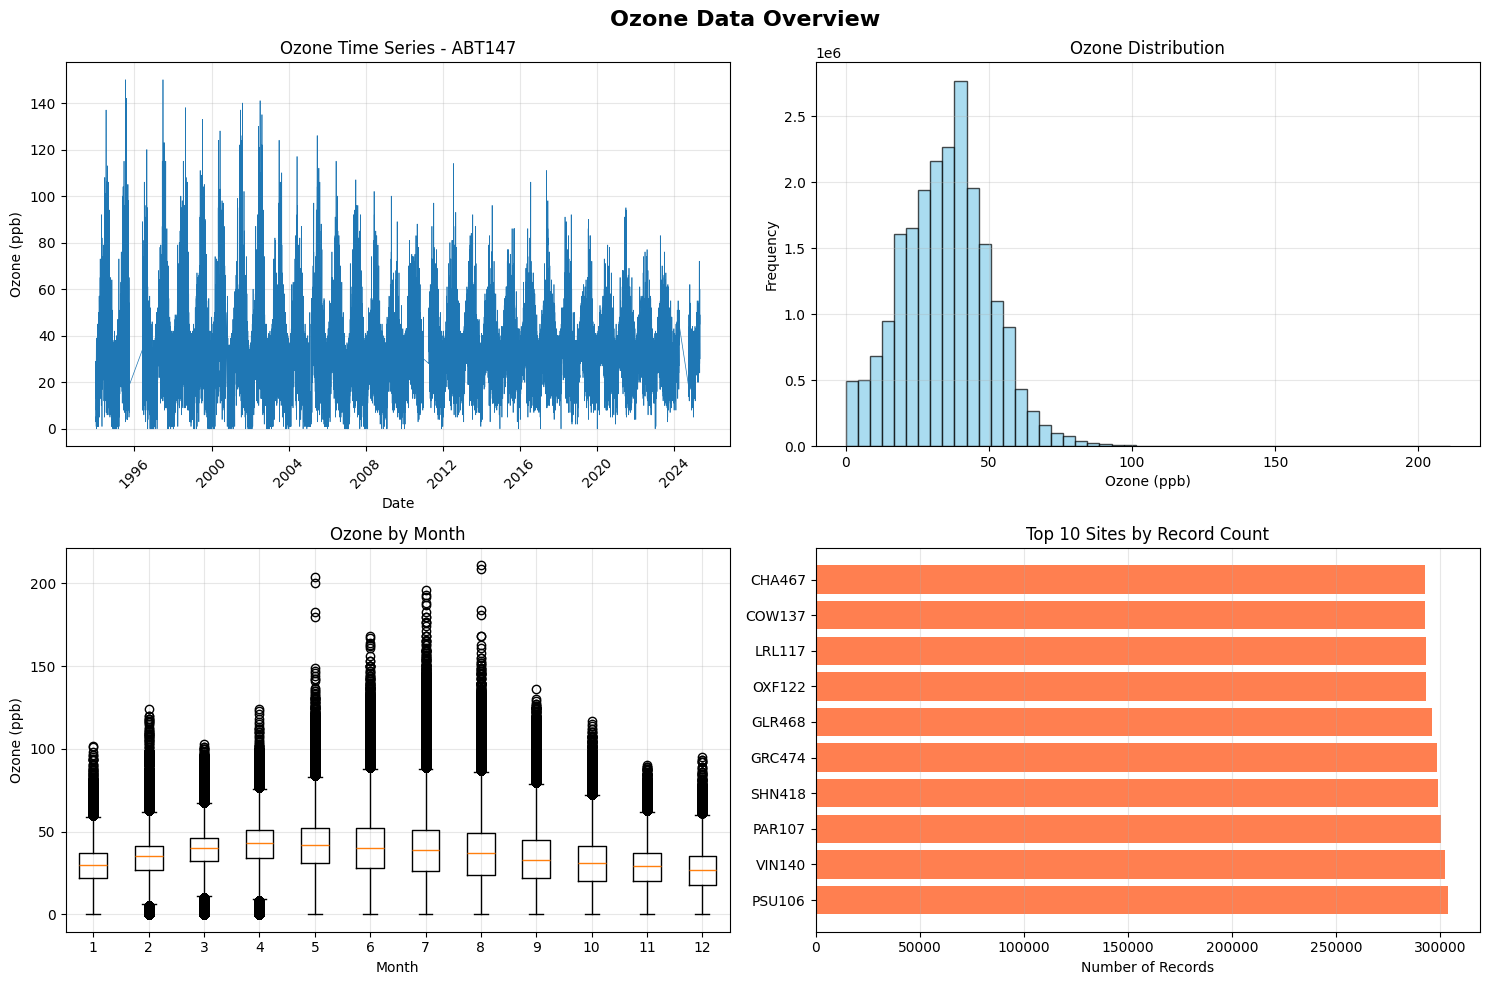


Files saved to: C:\MATH699P\Data\processed_data


In [ ]:

if not df_ozone.empty and 'OZONE' in df_ozone.columns and 'DATE_TIME' in df_ozone.columns:
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Ozone Data Overview', fontsize=16, fontweight='bold')
    
    if 'SITE_ID' in df_ozone.columns:
        first_site = df_ozone['SITE_ID'].iloc[0]
        site_data = df_ozone[df_ozone['SITE_ID'] == first_site].copy()
        site_data = site_data.sort_values('DATE_TIME')
        
        axes[0, 0].plot(site_data['DATE_TIME'], site_data['OZONE'], linewidth=0.5)
        axes[0, 0].set_title(f'Ozone Time Series - {first_site}')
        axes[0, 0].set_xlabel('Date')
        axes[0, 0].set_ylabel('Ozone (ppb)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].tick_params(axis='x', rotation=45)
    
    axes[0, 1].hist(df_ozone['OZONE'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 1].set_title('Ozone Distribution')
    axes[0, 1].set_xlabel('Ozone (ppb)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    df_ozone['month'] = df_ozone['DATE_TIME'].dt.month
    monthly_data = [df_ozone[df_ozone['month'] == m]['OZONE'].dropna() for m in range(1, 13)]
    axes[1, 0].boxplot(monthly_data, labels=range(1, 13))
    axes[1, 0].set_title('Ozone by Month')
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Ozone (ppb)')
    axes[1, 0].grid(True, alpha=0.3)
    
    if 'SITE_ID' in df_ozone.columns:
        site_counts = df_ozone['SITE_ID'].value_counts().head(10)
        axes[1, 1].barh(range(len(site_counts)), site_counts.values, color='coral')
        axes[1, 1].set_yticks(range(len(site_counts)))
        axes[1, 1].set_yticklabels(site_counts.index)
        axes[1, 1].set_title('Top 10 Sites by Record Count')
        axes[1, 1].set_xlabel('Number of Records')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    
    plot_file = os.path.join(PROCESSED_DIR, 'ozone_overview.png')
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    print(f"Saved visualization: {plot_file}")
    
    plt.show()
else:
    print("Insufficient data for visualization")


print(f"\nFiles saved to: {PROCESSED_DIR}")